In [4]:
import xarray as xr
import pandas as pd
import numpy as np

import hvplot.xarray
import hvplot.pandas

import matplotlib.pyplot as plt
from cycler import cycler

import hvplot.xarray
import hvplot.pandas
import holoviews as hv

import pynsitu as pyn
#from lib import KEYS, raw_dir, images_dir, doc_dir
import os
from glob import glob


In [ ]:
taps = generate_filter(band="low", dt=dt, T=T, bandwidth=cto)
        print(len(taps))
        try:
            vx = xr.DataArray(
                filtfilt(taps, 1, dss.drifter_vx), dims=["obs", "site_obs"]
            )

In [ ]:
w, hh = signal.freqz(h, worN=8000, fs=1 / dt)

In [18]:
dt = 10/(60*24)#10min in days

def plot_filter(T=12, dt=dt, bandwidth=2.5):

    taps = pyn.tseries.generate_filter(band="low", dt=dt, T=T, bandwidth=bandwidth)
    t = np.arange(0, taps.size) * dt

    H, omega = pyn.tseries.filter_response(taps, dt)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3))

    ax = axes[0]
    ax.plot(t, taps, color="teal")
    ax.set_xlabel("Convolution time [day]")
    ax.set_ylabel("Impulse response")
    ax.grid()

    ax = axes[1]
    ax.plot(omega, np.abs(H), color="teal")
    ax.set_xlabel("Frequency [cpd]")
    ax.axvline(bandwidth, ls="--", color="k")
    ax.annotate(r"$f_c = 2.5 cpd$", (bandwidth + 0.2, 1e-1))
    ax.set_ylabel("Frequency response [dB]")
    ax.set_yscale("log")
    ax.grid()
    fig.tight_layout()
    #path = os.path.join(
    #    images_dir, f"filter_caracteristic_{T}_{round(dt*24*60)}_{bandwidth}.png"
    #)
    #fig.savefig(path, dpi=250)

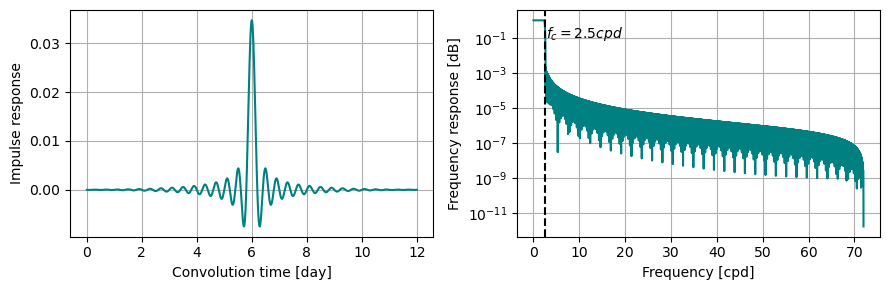

In [19]:
plot_filter()